In [11]:
from integrated_gradients.integrated_gradients import compute_integrated_gradients
from model.resnet50_utils import make_predictions_and_gradients
from PIL import Image
import torch
import numpy as np
from torchvision import transforms
from expected_gradients.expected_gradients import expected_gradients
from datasets import load_dataset
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import random

In [12]:
train_ds = ImageFolder(
    root="imagenette2-320\\imagenette2-320\\train"
)

In [13]:
import matplotlib.pyplot as plt

img, label = train_ds[random.randrange(len(train_ds))]
print(label)
img.show()

6


In [14]:
# make_predictions_and_gradients([Image.open("..\\Images\\1bd6987fa9219dec.jpg").convert("RGB")], 0)

num_steps = 20

img = img.convert("RGB").resize((224,224))
# img = Image.open("Images\\hund1.jpeg").convert("RGB").resize((224,224))

input_tensor = transforms.ToTensor()(img)

# input_tensor = PILToTensor()(Image.open("Images\\weimaraner-1381186_1920c6aeb.jpg").convert("RGB").resize((224,224))) 
print(input_tensor.shape)
gradients, preds = expected_gradients(input_tensor, 0, make_predictions_and_gradients, 5, num_steps)

torch.Size([3, 224, 224])
20
torch.Size([20, 1000])
tensor([-1.6871, -1.9085, -2.6543, -2.4738, -3.0825, -0.8166, -3.1687, -1.0465,
        -0.7456, -1.6550], grad_fn=<SliceBackward0>)
tensor(18.2723, grad_fn=<MaxBackward1>)
tensor(-6.1140, grad_fn=<MinBackward1>)
tensor(0.9890, grad_fn=<MaxBackward1>)
tensor(3.1950e-11, grad_fn=<MinBackward1>)
tensor(1., grad_fn=<SumBackward0>)
20
torch.Size([20, 1000])
tensor([-2.0779,  2.2330,  0.2365, -0.3172,  0.7277, -0.1887, -1.8791,  1.8336,
        -0.4591, -1.0481], grad_fn=<SliceBackward0>)
tensor(16.9621, grad_fn=<MaxBackward1>)
tensor(-6.2322, grad_fn=<MinBackward1>)
tensor(0.9986, grad_fn=<MaxBackward1>)
tensor(1.1142e-10, grad_fn=<MinBackward1>)
tensor(1.0000, grad_fn=<SumBackward0>)
20
torch.Size([20, 1000])
tensor([-0.5900, -2.6342, -0.0439,  0.8310, -0.1980, -0.6917,  0.6438,  0.8840,
        -1.4511,  2.5715], grad_fn=<SliceBackward0>)
tensor(16.1618, grad_fn=<MaxBackward1>)
tensor(-5.9282, grad_fn=<MinBackward1>)
tensor(0.9890, grad

In [15]:
print(gradients.shape)
print(preds.shape)

torch.Size([3, 224, 224])
torch.Size([20, 1000])


In [16]:
import urllib.request

url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = urllib.request.urlopen(url).read().decode("utf-8").split("\n")

In [17]:
print(preds.shape)
max_class = torch.argmax(preds[num_steps-1])
print(max_class)
print(labels[max_class])

pred = torch.tensor(preds[-1])

top5 = torch.argsort(pred, descending=True)[:5]

for idx in top5:
    print(idx.item(), labels[idx.item()], pred[idx].item())

print(input_tensor.shape)
print(gradients.shape)

torch.Size([20, 1000])
tensor(569)
garbage truck
569 garbage truck 0.9889675378799438
675 moving van 0.0020608678460121155
864 tow truck 0.0013812073739245534
517 crane 0.0012919481378048658
408 amphibian 0.0009807378519326448
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


C:\Users\Oswin\AppData\Local\Temp\ipykernel_15420\2777618892.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred = torch.tensor(preds[-1])


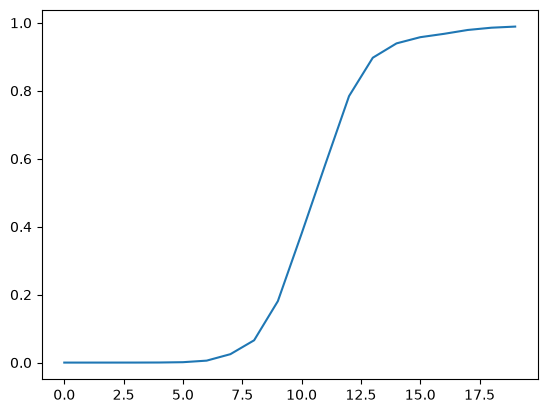

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(range(num_steps), preds.detach().numpy()[:,max_class])
plt.show()

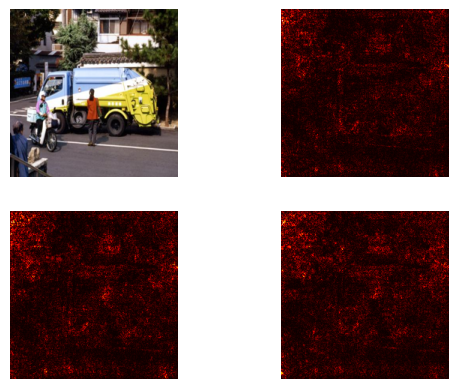

In [19]:
fig, axs = plt.subplots(2, 2)

axs[0, 0].set_axis_off()
axs[1, 0].set_axis_off()
axs[0, 1].set_axis_off()
axs[1, 1].set_axis_off()

norm_gradients = (gradients.abs() - gradients.abs().min()) / (gradients.abs().max() - gradients.abs().min())

axs[0, 0].imshow(input_tensor.permute(1,2,0))
axs[0, 1].imshow(norm_gradients.permute(1,2,0)[:,:,0]*255, cmap="hot")
axs[1, 0].imshow(norm_gradients.permute(1,2,0)[:,:,1]*255, cmap="hot")
axs[1, 1].imshow(norm_gradients.permute(1,2,0)[:,:,2]*255, cmap="hot")
plt.show()

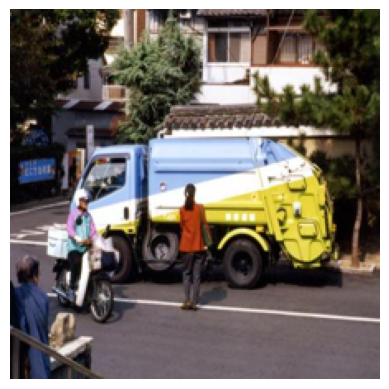

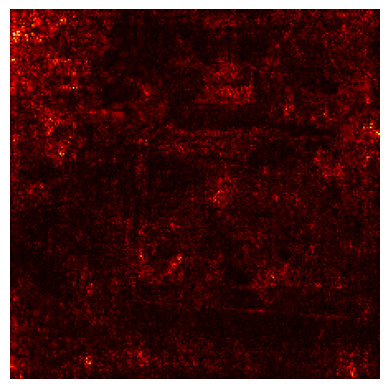

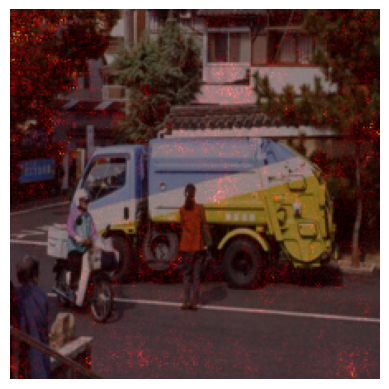

In [20]:
fig, ax = plt.subplots()
ax.set_axis_off()
ax.imshow(input_tensor.permute(1,2,0))
plt.show()

fig, ax = plt.subplots()
ax.imshow(norm_gradients.permute(1,2,0).sum(dim=2), cmap="hot", alpha=1)
ax.set_axis_off()
plt.show()

fig, ax = plt.subplots()
ax.imshow(input_tensor.permute(1,2,0))
ax.imshow(norm_gradients.permute(1,2,0).sum(dim=2), cmap="hot", alpha=0.5)
ax.set_axis_off()
plt.show()